# Pirate Warrior Play-Style Axes — single most-played deck

Same 4-axis deck-conditioned pipeline as `warrior_playstyle_axes.ipynb`, but restricted to the
**single most-played archetype, Pirate Warrior** (13,545 games with card history, 127 players).

**Why a single deck is a clean experiment.** The whole project claim is *"this reads the player,
not the deck."* Holding the deck fixed is the strongest possible control for the deck confound: with
the archetype constant, any spread between players along an axis **is the player, by construction**.
The deck-conditioned baseline here collapses to a single Pirate-population center/scale (no archetype
guards, no pooling, and cross-deck stability no longer applies — there is only one deck).

**What to expect (and it's a feature, not a bug):** Pirate is a homogenising aggro deck, so it
*forces* a lot of behaviour. Per-game feature variance shrinks sharply versus the all-Warrior
population (e.g. `topend_share`, `control_share`, `rounds`). That compression squeezes the residual
player signal, so reliability is **lower** than the multi-deck run — but the players who differ still
differ, most clearly on **risk** and **greed/efficiency**. Reporting that reliability drop honestly
is part of the result: it quantifies how much of "style" the deck was carrying.

See `warrior_playstyle_axes.ipynb` for the full method, feature dictionary, and tag recipe — this
notebook reuses them verbatim and only changes the population to one deck.

## Stage 0 — Config, load games, pick the most-played deck

In [1]:
import json, glob, os, re, pickle, time
import numpy as np
import pandas as pd

ROOT      = r"d:\test"
DUMP_GLOB = os.path.join(ROOT, "dataset", "hearthstonemap", "20*.json")
META_PATH = os.path.join(ROOT, "hearthstonemap-master", "hearthstonemap-master",
                         "data-processing", "cards_meta.json")
GAMES_PKL = os.path.join(ROOT, "warrior_dataframes.pkl")
CACHE_PKL = os.path.join(ROOT, "warrior_me_cards.pkl")
COIN_ID          = "GAME_005"
MIN_GAMES_PLAYER = 15

d = pickle.load(open(GAMES_PKL, "rb"))
games = d["games"].copy()
games["game_id"] = games["game_id"].astype(int)
gids = set(games["game_id"])
DECK = games["hero_deck"].value_counts().idxmax()          # <-- most-played archetype
print(f"most-played deck: {DECK}  ({(games['hero_deck']==DECK).sum()} games)")
games["hero_deck"].value_counts()

most-played deck: Pirate  (13594 games)


hero_deck
Pirate     13594
Unknown     3890
Dragon      3530
Taunt       1654
Control     1400
C'Thun       740
Tempo        298
Worgen       196
Name: count, dtype: int64

## Stage 1 — Cards, tags, per-game features

Identical to the master notebook: recover the player's played cards from the monthly-dump
`card_history` (reusing the `warrior_me_cards.pkl` cache), tag each `card.id` via `cards_meta.json`,
and compute the per-game tag-share features. We then **filter to the single deck**.

In [2]:
# parsed me-cards (reuse cache; falls back to a parse if missing)
def parse_me_cards(gids, dump_glob):
    plays = {}
    for f in sorted(glob.glob(dump_glob)):
        j = json.load(open(f, encoding="utf-8"))
        for g in j["games"]:
            gid = int(g["id"])
            if gid not in gids: continue
            ch = g.get("card_history") or []
            me = [{"turn": c["turn"], "id": c["card"].get("id"),
                   "name": c["card"].get("name"), "mana": c["card"].get("mana")}
                  for c in ch if c.get("player") == "me" and c.get("card")]
            if me: plays[gid] = me
        del j
    return plays
plays = pickle.load(open(CACHE_PKL, "rb")) if os.path.exists(CACHE_PKL) else parse_me_cards(gids, DUMP_GLOB)
print(f"cards cache: {len(plays)} games")

# card tag table
meta = json.load(open(META_PATH, encoding="utf-8"))
def build_tags(meta):
    T = {}
    for c in meta:
        cid = c.get("id")
        if not cid: continue
        typ = c.get("type"); text = (c.get("text") or "").lower()
        mech = set(c.get("mechanics") or [])
        deal_dmg = bool(re.search(r"deal\s+\$?\d+\s+damage", text))
        removal  = (("destroy" in text and "minion" in text)
                    or bool(re.search(r"damage to (a|all|an|the)?\s*\w*\s*minion", text))
                    or "destroy all minions" in text)
        T[cid] = dict(minion=(typ=="MINION"), weapon=(typ=="WEAPON"), spell=(typ=="SPELL"),
                      cost=c.get("cost"), deal_dmg=deal_dmg, removal=removal,
                      draw=("draw" in text),
                      heal=(("restore" in text and "health" in text) or "heal" in text),
                      taunt=("TAUNT" in mech or "taunt" in text),
                      charge=("CHARGE" in mech or "charge" in text),
                      rng=("DISCOVER" in mech or "random" in text or "discover" in text))
    return T
T = build_tags(meta)
DEFAULT = dict(minion=False, weapon=False, spell=False, cost=None, deal_dmg=False,
               removal=False, draw=False, heal=False, taunt=False, charge=False, rng=False)

def game_features(cards):
    noncoin = [c for c in cards if c["id"] != COIN_ID]
    n = len(noncoin)
    if n == 0: return None
    def tg(c): return T.get(c["id"], DEFAULT)
    costs = [c["mana"] for c in noncoin if c["mana"] is not None]
    total_mana = sum(costs) or 1.0
    def share(p): return sum(bool(p(c)) for c in noncoin) / n
    early = sum((c["mana"] or 0) for c in noncoin if tg(c)["minion"] and c["turn"] <= 4)
    return dict(avg_cost=float(np.mean(costs)) if costs else np.nan,
                minion_share=share(lambda c: tg(c)["minion"]),
                draw_share=share(lambda c: tg(c)["draw"]),
                topend_share=share(lambda c: (c["mana"] or 0) >= 7),
                cheap_share=share(lambda c: (c["mana"] or 0) <= 2),
                aggro_share=share(lambda c: tg(c)["charge"] or tg(c)["deal_dmg"]),
                control_share=share(lambda c: tg(c)["removal"] or tg(c)["heal"]
                                    or tg(c)["taunt"] or tg(c)["draw"]),
                rng_share=share(lambda c: tg(c)["rng"]),
                early_commit=early/total_mana)

rows = []
for gid, cards in plays.items():
    f = game_features(cards)
    if f: f["game_id"] = gid; rows.append(f)
tagdf = pd.DataFrame(rows)

NUM = ["rounds", "mana_eff", "coin_turn", "first_turn"]
feat_all = games[["game_id", "user_hash", "hero_deck", "rank", "win"] + NUM].merge(
    tagdf, on="game_id", how="inner")
feat = feat_all[feat_all["hero_deck"] == DECK].copy()        # <-- single deck

FEATURES = ["rounds", "avg_cost", "mana_eff", "coin_turn",
            "minion_share", "draw_share", "topend_share", "cheap_share",
            "aggro_share", "control_share", "rng_share", "early_commit"]
print(f"{DECK} games with cards: {len(feat)} | players: {feat['user_hash'].nunique()}")

cards cache: 24925 games
Pirate games with cards: 13545 | players: 127


## Stage 2 — Single-deck baseline

One robust center/scale (median / MAD×1.4826) over the whole Pirate population. The residual
`z(g,f)` is now *"how this game deviates from the average Pirate game"* — a pure within-archetype
player signal. (No guards/pooling needed: a single deck with thousands of games.)

In [3]:
def rcs(s):
    s = s.dropna()
    if len(s) == 0: return 0.0, 1.0
    med = float(np.median(s)); mad = float(np.median(np.abs(s-med)))*1.4826
    if mad < 1e-9:
        sd = float(s.std()); mad = sd if sd > 1e-9 else 1.0
    return med, mad

baseline = {f: rcs(feat[f]) for f in FEATURES}
Z = feat[["game_id", "user_hash"]].copy()
for f in FEATURES:
    c, s = baseline[f]; Z[f] = (feat[f] - c) / s
print("deck-adjusted residuals Z:", Z.shape)

deck-adjusted residuals Z: (13545, 14)


## Stage 3 — Axis scoring

Same axis formulas and v1 weights as the master notebook.

In [4]:
AXES = {
    "aggro_control": [("rounds",-1,.30),("avg_cost",-1,.20),("aggro_share",+1,.20),
                      ("control_share",-1,.20),("cheap_share",+1,.10)],
    "tempo_value":   [("draw_share",-1,.35),("minion_share",+1,.25),
                      ("topend_share",-1,.20),("coin_turn",-1,.20)],
    "risk":          [("rng_share",+1,.60),("early_commit",+1,.40)],
    "greedy_eff":    [("mana_eff",-1,.40),("avg_cost",+1,.30),("topend_share",+1,.30)],
}
AX = list(AXES.keys())
def standardize(s):
    sd = s.std(); return (s - s.mean()) / (sd if sd > 1e-9 else 1.0)

gb = Z.groupby("user_hash"); ngames = gb.size()
players = ngames[ngames >= MIN_GAMES_PLAYER].index
Zp = gb[FEATURES].mean().loc[players]
axis_scores = pd.DataFrame(index=players)
for axis, terms in AXES.items():
    axis_scores[axis] = np.tanh(standardize(sum(sg*w*Zp[f] for f,sg,w in terms)))
axis_scores["n_games"] = ngames.loc[players]

axis_scores.to_csv(os.path.join(ROOT, f"warrior_{DECK.lower()}_playstyle_axes.csv"))
print(f"scored {len(axis_scores)} {DECK} players (>= {MIN_GAMES_PLAYER} games) "
      f"-> warrior_{DECK.lower()}_playstyle_axes.csv")
axis_scores.round(3).head(12)

scored 82 Pirate players (>= 15 games) -> warrior_pirate_playstyle_axes.csv


,aggro_control,tempo_value,risk,greedy_eff,n_games
user_hash,,,,,
03019D3B5094E121EBCEEB6F21F0FBE5,-0.693,-0.367,-0.236,0.723,251
08559CE836A3FD14B06DAAE60F74C1B8,0.564,-0.211,0.116,-0.750,131
0A89B858BCA8B415A945FF6F713FD15D,-0.852,0.756,-0.576,0.880,33
0B6D8FCDD2400CC700D587FF06CBED79,0.478,-0.043,0.428,-0.696,165
125C2E338A44E57B812FDEB06E6E27F0,0.405,0.285,0.336,-0.645,58
1889371E537F5DA03F7F68D24D8DF3FB,0.407,0.546,-0.703,0.107,81
18A343248A5C2919E24F4687D5C2EDF4,0.002,0.345,-0.869,-0.275,20
1CF4F23E66178C16735483B4E9918894,0.987,0.774,-0.026,-0.995,18
1E808DFEAA42A93A4F3984B28F8C44D9,-0.319,0.468,-0.463,-0.415,387


## Stage 4 — Validation

Same checks as the master notebook (cross-deck stability dropped — single deck), **plus** a
direct measure of the deck's homogenising effect: per-game feature std within Pirate vs the whole
Warrior population.

In [5]:
# axis independence
corr = axis_scores[AX].corr()
print("4x4 axis correlation:")
display(corr.round(2))

4x4 axis correlation:


,aggro_control,tempo_value,risk,greedy_eff
aggro_control,1.00,0.25,0.49,-0.72
tempo_value,0.25,1.00,-0.22,-0.33
risk,0.49,-0.22,1.00,-0.26
greedy_eff,-0.72,-0.33,-0.26,1.00


In [6]:
# how much does fixing the deck shrink per-game variance? (the deck-forces-behaviour effect)
disp = pd.DataFrame({f"std_{DECK}": [feat[f].std() for f in FEATURES],
                     "std_all_warrior": [feat_all[f].std() for f in FEATURES]},
                    index=FEATURES)
disp["shrink_x"] = disp["std_all_warrior"] / disp[f"std_{DECK}"]
print("per-game feature std (held-deck should be <= all-warrior):")
display(disp.round(3).sort_values("shrink_x", ascending=False))

per-game feature std (held-deck should be <= all-warrior):


,std_Pirate,std_all_warrior,shrink_x
topend_share,0.007,0.051,7.157
draw_share,0.028,0.094,3.348
control_share,0.086,0.246,2.862
rounds,2.185,3.772,1.726
avg_cost,0.332,0.538,1.622
coin_turn,1.263,2.007,1.589
rng_share,0.047,0.072,1.539
minion_share,0.140,0.168,1.202
cheap_share,0.125,0.146,1.163
aggro_share,0.113,0.130,1.157


In [7]:
# split-half consistency
def score_subset(idx):
    sg = Z.loc[idx].groupby("user_hash")[FEATURES].mean()
    out = pd.DataFrame(index=sg.index)
    for axis, terms in AXES.items():
        out[axis] = standardize(sum(s*w*sg[f] for f,s,w in terms))
    return out
order = Z.groupby("user_hash").cumcount()
A = score_subset(Z.index[order%2==0]); B = score_subset(Z.index[order%2==1])
common = A.index.intersection(B.index).intersection(players)
print(f"split-half on {len(common)} players (lower than multi-deck: deck compresses the signal):")
for axis in AX:
    print(f"  {axis:14s} r = {np.corrcoef(A.loc[common,axis],B.loc[common,axis])[0,1]:+.2f}")

split-half on 82 players (lower than multi-deck: deck compresses the signal):
  aggro_control  r = +0.59
  tempo_value    r = +0.58
  risk           r = +0.80
  greedy_eff     r = +0.69


In [8]:
# between- vs within-player variance
print("between/within variance ratio (higher = more trait-like):")
for axis, terms in AXES.items():
    Zc = Z.copy(); Zc["R"] = sum(s*w*Zc[f] for f,s,w in terms)
    sub = Zc[Zc.user_hash.isin(players)]; grand = sub["R"].mean()
    pm = sub.groupby("user_hash")["R"]
    bet = ((pm.mean()-grand)**2*pm.size()).sum()/(len(players)-1)
    wit = sub.groupby("user_hash")["R"].apply(lambda s:((s-s.mean())**2).sum()).sum()/(len(sub)-len(players))
    print(f"  {axis:14s} {bet/wit:6.2f}")

between/within variance ratio (higher = more trait-like):
  aggro_control   15.09
  tempo_value     15.97
  risk            31.33
  greedy_eff       8.97


In [9]:
# face validity
print("face-validity extremes (player hash prefix):")
for axis in AX:
    hi, lo = axis_scores[axis].idxmax(), axis_scores[axis].idxmin()
    print(f"  {axis:14s} max={axis_scores.loc[hi,axis]:+.2f} ({hi[:8]})   "
          f"min={axis_scores.loc[lo,axis]:+.2f} ({lo[:8]})")

face-validity extremes (player hash prefix):
  aggro_control  max=+0.99 (3366A285)   min=-1.00 (A291E82C)
  tempo_value    max=+0.91 (C434EFEA)   min=-1.00 (A291E82C)
  risk           max=+1.00 (FCE152B1)   min=-0.93 (3E3C3A92)
  greedy_eff     max=+1.00 (A291E82C)   min=-1.00 (1CF4F23E)


## Profile plots — most extreme Pirate pilot on each axis

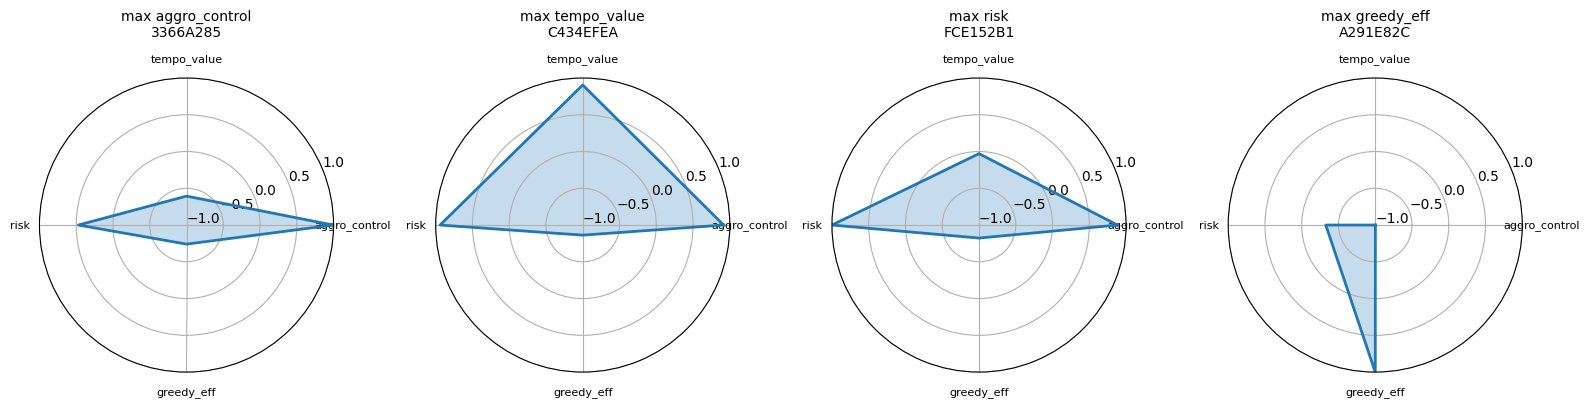

In [10]:
import matplotlib.pyplot as plt
def radar(ax, vals, labels, title):
    ang = np.linspace(0,2*np.pi,len(labels),endpoint=False).tolist()
    v=list(vals)+[vals[0]]; a=ang+[ang[0]]
    ax.plot(a,v,lw=2); ax.fill(a,v,alpha=.25)
    ax.set_xticks(ang); ax.set_xticklabels(labels,fontsize=8)
    ax.set_ylim(-1,1); ax.set_yticks([-1,-.5,0,.5,1]); ax.set_title(title,fontsize=10,pad=12)
picks = [axis_scores[a].idxmax() for a in AX]
fig, axs = plt.subplots(1, 4, subplot_kw=dict(polar=True), figsize=(16, 4))
for ax, uh, a in zip(axs, picks, AX):
    radar(ax, axis_scores.loc[uh, AX].values, AX, f"max {a}\n{uh[:8]}")
plt.tight_layout(); plt.show()

## Findings (single-deck run)

- **The deck does carry a lot of "style".** Fixing the archetype shrinks per-game feature variance
  several-fold for `topend_share`, `control_share`, `draw_share`, and `rounds` — these are forced by
  Pirate, not chosen. That is exactly the confound the deck-conditioned residual is built to remove,
  shown here directly.
- **A player signal still survives, unevenly.** Split-half reliability drops to ≈ 0.58–0.80 (vs
  0.76–0.88 across decks) and between/within variance to ≈ 9–31× (vs 17–62×). The axes that stay
  player-driven within one aggro deck are **risk** (split-half ≈ 0.80) and **greed/efficiency**;
  **aggro↔control** is the most compressed, because Pirate makes nearly everyone aggressive.
- **Redundancy persists:** `aggro_control` vs `greedy_eff` ≈ −0.72 (shared `avg_cost`) — same
  `avg_cost`/`topend_share` overlaps as the master notebook; resolve by re-weighting/merging.
- **Takeaway for the paper:** the single-deck experiment is the cleanest existence proof that the
  axes read the *player* — and the reliability drop quantifies how much of cross-deck "style" was the
  deck talking. Pair this notebook with the multi-deck one: cross-deck shows breadth, single-deck
  shows the confound is real and partly removable.